# Project data exploration - looking at relplot and scatter plots
Using a dataset that your group is consider using for the term project, let's do some data exploring of the different features in your dataset and their relationships



```
# This is formatted as code
```

Group name: Comparative Analysis on Prescription Drugs Using Medicaid Info

Created by Sana Al Hamimidi, Aaditya Deshmukh, Nyi Wai Yan Tun

Last updated: 3/22/2026

Briefly describe your dataset: We are using the State Drug Utilization Data 2025 dataset. This dataset contains Medicaid prescription drug utilization and reimbursement information reported by U.S. states. It includes features such as state, drug name, number of prescriptions, units reimbursed, and reimbursement amounts, which helps us study drug usage and spending patterns.

Import your data. If you want to mount your Google drive you can use `from google.colab import drive` and `drive.mount('/content/drive')`

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Make plots look nicer
sns.set_theme(style="whitegrid")

# Load dataset
# Change the file path/name if needed
df = pd.read_csv("https://download.medicaid.gov/data/sdud-2025-updated-dec2025.csv")

# Look at the first few rows
df.head()

,Utilization Type,State,NDC,Labeler Code,Product Code,Package Size,Year,Quarter,Suppression Used,Product Name,Units Reimbursed,Number of Prescriptions,Total Amount Reimbursed,Medicaid Amount Reimbursed,Non Medicaid Amount Reimbursed
0,FFSU,AK,2143380,2,1433,80,2025,2,False,TRULICITY,216.0,107.0,102976.40,98630.87,4345.53
1,FFSU,AK,2143480,2,1434,80,2025,2,False,TRULICITY,218.0,109.0,104481.92,101806.64,2675.28
2,FFSU,AK,2143611,2,1436,11,2025,2,False,EMGALITY P,21.0,20.0,15227.25,15227.25,0.00
3,FFSU,AK,2144511,2,1445,11,2025,2,False,TALTZ AUTO,33.0,30.0,231532.28,231532.28,0.00
4,FFSU,AK,2144527,2,1445,27,2025,2,True,TALTZ AUTO,NaN,NaN,NaN,NaN,NaN


### Q1: Show the number of missing data in each column of the dataframe

In [3]:
# Number of missing values in each column
df.isnull().sum()

,0
Utilization Type,0
State,0
NDC,0
Labeler Code,0
Product Code,0
Package Size,0
Year,0
Quarter,0
Suppression Used,0
Product Name,0


### Q2: Show the data type for each column of the dataframe

In [4]:
df.dtypes

,0
Utilization Type,object
State,object
NDC,int64
Labeler Code,int64
Product Code,int64
Package Size,int64
Year,int64
Quarter,int64
Suppression Used,bool
Product Name,object


### Q3: Create a pair plot to show pairwise relationship in this dataset.
Draw the pairwise polynomial regression lines in a different color than the data points. Use a light color for the data points to deemphasizing the points to make the regression line stand out. Include a meaningful title to the plot.

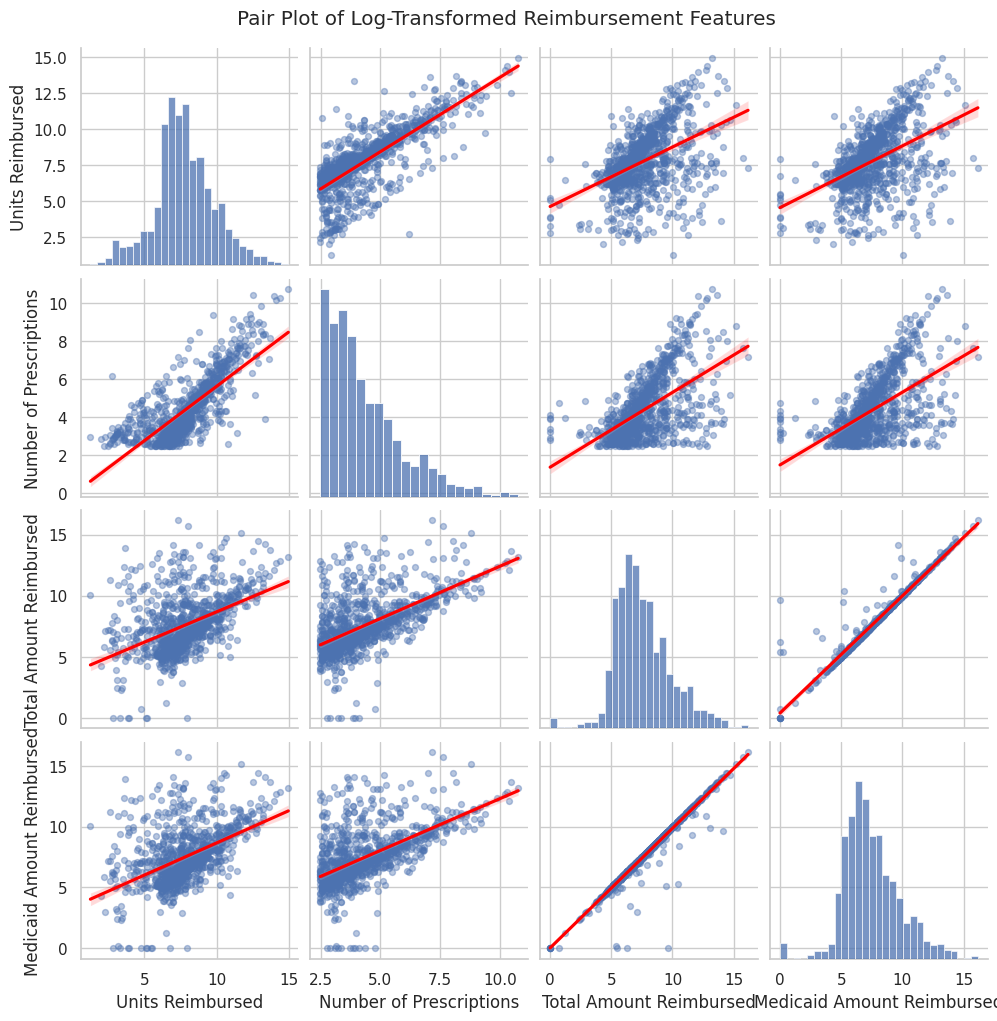

In [16]:
import numpy as np

selected_cols = [
    'Units Reimbursed',
    'Number of Prescriptions',
    'Total Amount Reimbursed',
    'Medicaid Amount Reimbursed'
]

q3_df = df[selected_cols].dropna().copy()


for col in selected_cols:
    q3_df = q3_df[q3_df[col] >= 0]

q3_df = q3_df.sample(n=min(1000, len(q3_df)), random_state=42)


for col in selected_cols:
    q3_df[col] = np.log1p(q3_df[col])

g = sns.pairplot(
    q3_df,
    kind='reg',
    plot_kws={
        'scatter_kws': {'alpha': 0.4, 's': 18},
        'line_kws': {'color': 'red'}
    }
)

g.fig.suptitle("Pair Plot of Log-Transformed Reimbursement Features", y=1.02)
plt.show()

### Q4: Plot a regression line and confidence interval
Select two of the features from your dataset and create a lmplot that shows the linear regression between them. Filter your data as you see fit. Include a meaningful title for the plot.

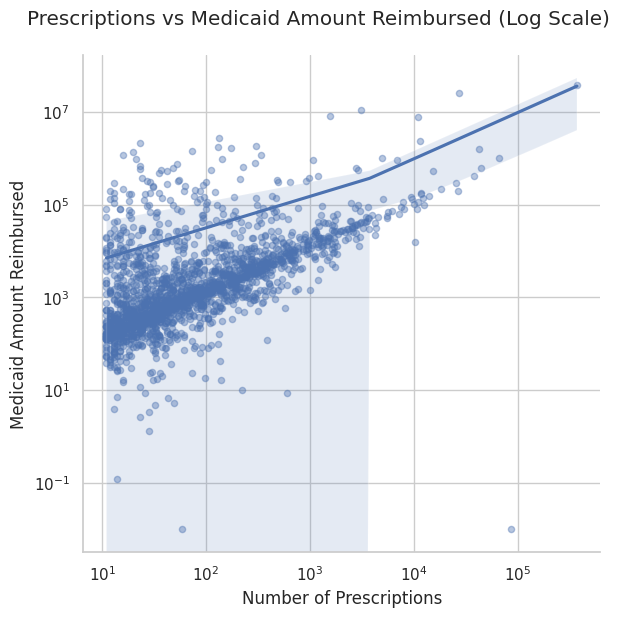

In [14]:
df.columns.tolist()
plot_df = df[['Number of Prescriptions', 'Medicaid Amount Reimbursed']].dropna()

# keep only positive values
plot_df = plot_df[
    (plot_df['Number of Prescriptions'] > 0) &
    (plot_df['Medicaid Amount Reimbursed'] > 0)
]

plot_df = plot_df.sample(n=min(2000, len(plot_df)), random_state=42)

g = sns.lmplot(
    data=plot_df,
    x='Number of Prescriptions',
    y='Medicaid Amount Reimbursed',
    height=6,
    scatter_kws={'alpha':0.4, 's':20}
)

g.set(xscale='log', yscale='log')
g.fig.suptitle("Prescriptions vs Medicaid Amount Reimbursed (Log Scale)", y=1.02)
plt.show()

### Q5. Create a relplot that shows multiple features in a single plot.
Select two features from your dataset and plot a scatter plot. Select two additional features you want to highlight in your data points using `hue` and `size`. Include a meaningful title to the plot.

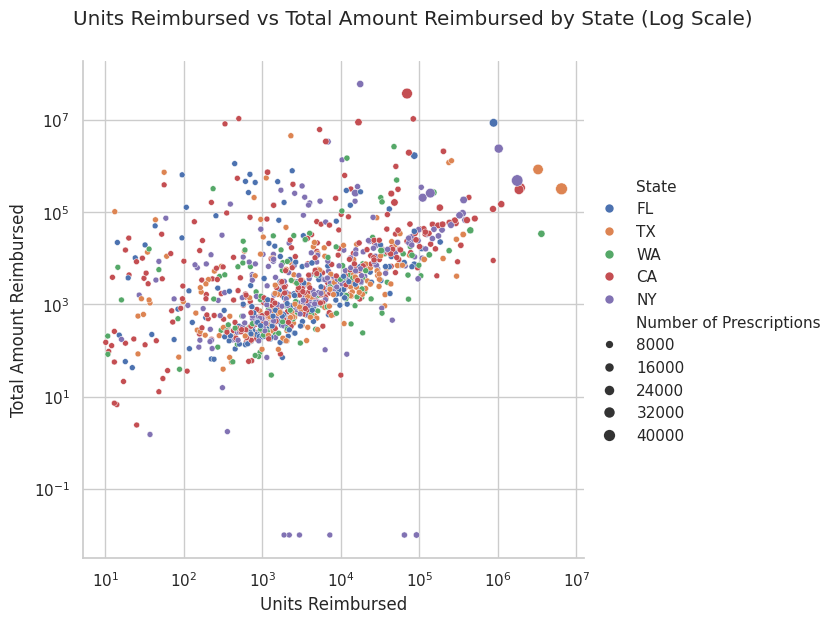

In [13]:
top_states = ['CA', 'TX', 'NY', 'FL', 'WA']

rel_df = df[['Units Reimbursed', 'Total Amount Reimbursed', 'State', 'Number of Prescriptions']].dropna()
rel_df = rel_df[rel_df['State'].isin(top_states)]

# keep only positive values for log scale
rel_df = rel_df[
    (rel_df['Units Reimbursed'] > 0) &
    (rel_df['Total Amount Reimbursed'] > 0) &
    (rel_df['Number of Prescriptions'] > 0)
]

rel_df = rel_df.sample(n=min(1000, len(rel_df)), random_state=42)

g = sns.relplot(
    data=rel_df,
    x='Units Reimbursed',
    y='Total Amount Reimbursed',
    hue='State',
    size='Number of Prescriptions',
    height=6
)

g.set(xscale='log', yscale='log')
g.fig.suptitle("Units Reimbursed vs Total Amount Reimbursed by State (Log Scale)", y=1.03)
plt.show()

### Q6: Create a plot with small multiples plots
Select two features from your dataset and show the relationship between the features with an additional feature as the single category. Organize the multiple plots to have 3 plots per row. Set the `height` of the plot to 5 and the size the of data point to 20. Include a meaningful title in the plot.

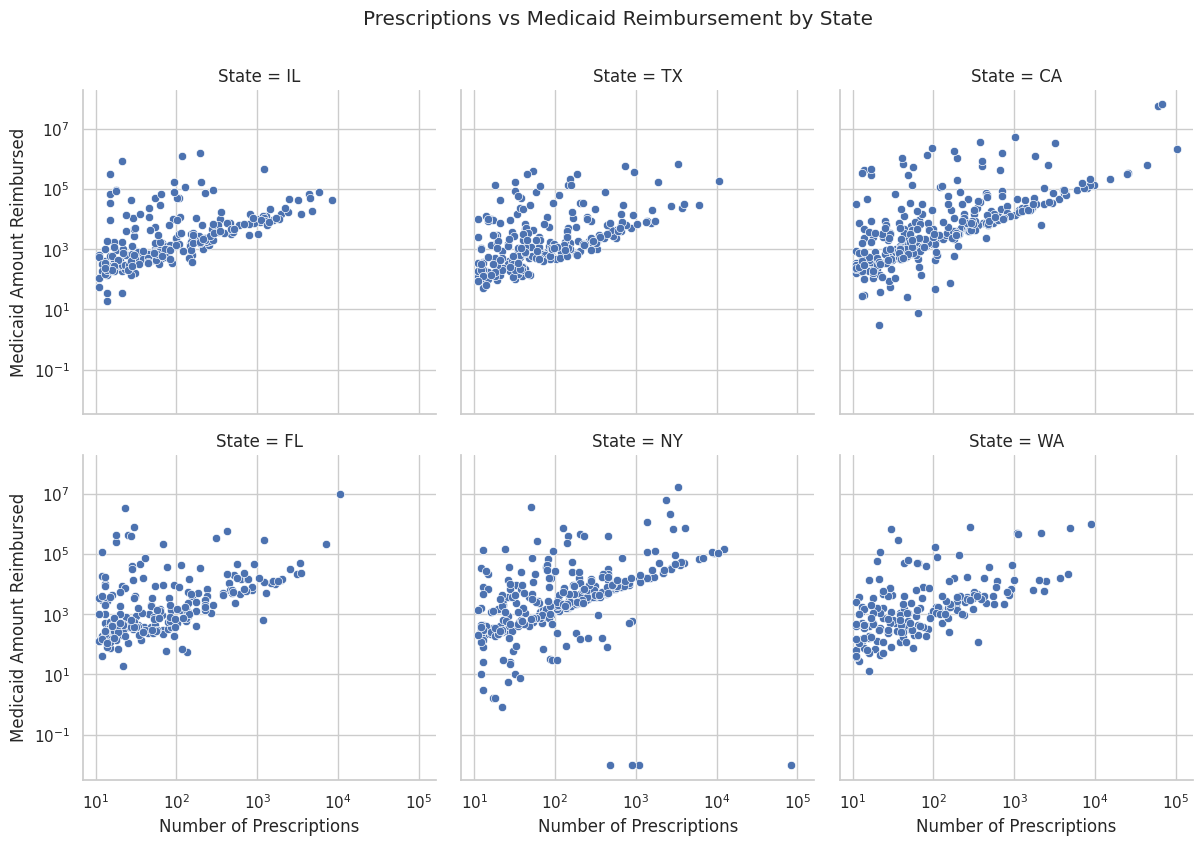

In [15]:
top_states = ['CA', 'TX', 'NY', 'FL', 'WA', 'IL']

multi_df = df[['Number of Prescriptions', 'Medicaid Amount Reimbursed', 'State']].dropna()
multi_df = multi_df[multi_df['State'].isin(top_states)]
multi_df = multi_df[
    (multi_df['Number of Prescriptions'] > 0) &
    (multi_df['Medicaid Amount Reimbursed'] > 0)
]
multi_df = multi_df.sample(n=min(1500, len(multi_df)), random_state=42)

g = sns.relplot(
    data=multi_df,
    x='Number of Prescriptions',
    y='Medicaid Amount Reimbursed',
    col='State',
    col_wrap=3,
    height=4
)

g.set(xscale='log', yscale='log')
g.fig.suptitle("Prescriptions vs Medicaid Reimbursement by State", y=1.05)
plt.show()